# Taller 6

## 1. Operadores de dilatación y erosión

### 1.1 Cree una nueva sección en su notebook.

### 1.2 Cargue y visualice la imagen morpho.png

### 1.3 Haga una umbralización de esta imagen, para obtener objetos negros sobre fondo blanco (umbral alrededor de 115).

In [137]:
# librerías
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from skimage.morphology import dilation, erosion, opening, closing
from skimage.morphology import footprint_rectangle
from scipy.ndimage import morphological_gradient
from skimage.filters import sobel_h, sobel_v, sobel
from skimage.measure import label
from skimage import exposure
from scipy.ndimage import distance_transform_edt



In [2]:
# leer dierectorio de imagenes
images_path = 'images/'

os.listdir(images_path)

['MORPHO.png']

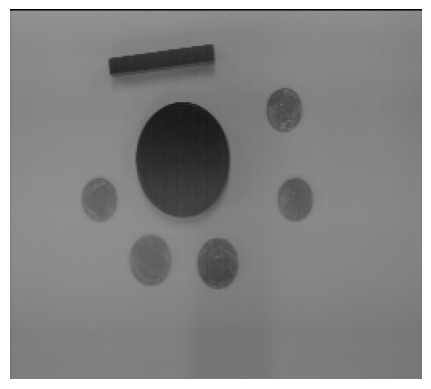

In [4]:
# leer la imagen morpho
morpho_image = cv2.imread(images_path+'MORPHO.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(morpho_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

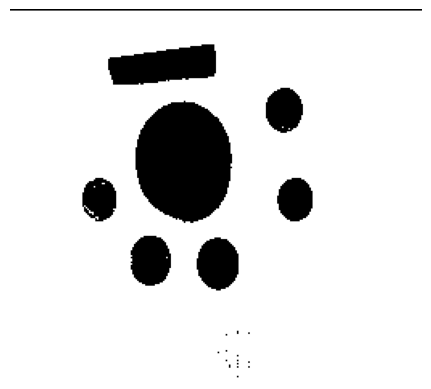

In [6]:
# umbralización
thres_value, morpho_umbralized = cv2.threshold(morpho_image, 115, 255, cv2.THRESH_BINARY)

# visualizar
plt.imshow(morpho_umbralized, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


### 1.4 Sobre la imagen binaria efectúe una dilatación con un elemento estructurante o máscara cuadrada de 29x29. ¿Qué obtiene como resultado?

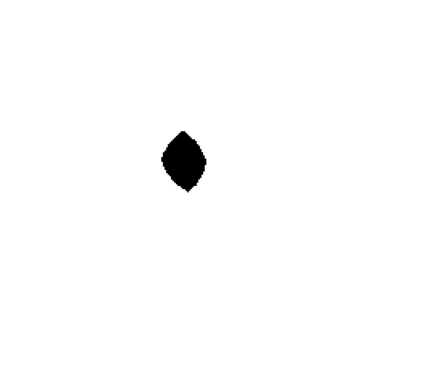

In [12]:
# dilatar con rectangulo de 29x29
structuring_element = footprint_rectangle(shape = (29, 29))
morpho_binary_dilated = dilation(morpho_umbralized, footprint=structuring_element)

# visualizar
plt.imshow(morpho_binary_dilated, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.5 Sobre la imagen resultante, haga una erosión con la misma máscara. ¿Cómo es el objeto obtenido con respecto al original?

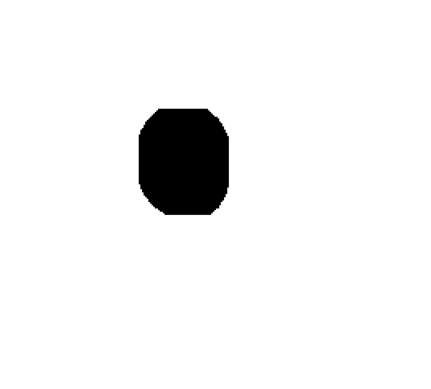

In [13]:
# erosionar con rectangulo de 29x29
morpho_binary_dilated_eroded = erosion(morpho_binary_dilated, footprint=structuring_element)

# visualizar
plt.imshow(morpho_binary_dilated_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.6 Sobre la imagen resultado del punto anterior, haga una erosión con una máscara en cruz, de tamaño 11x11. Las máscaras en cruz deben crearse generando una matriz de nxn (tamaño deseado) y colocando 1’ s en la cruz. Los demás elementos se deben dejar vacíos (SIN CEROS).

In [14]:
cross = np.zeros((11, 11), dtype=np.uint8)
cross[5, :] = 1
cross[:, 5] = 1
cross

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]], dtype=uint8)

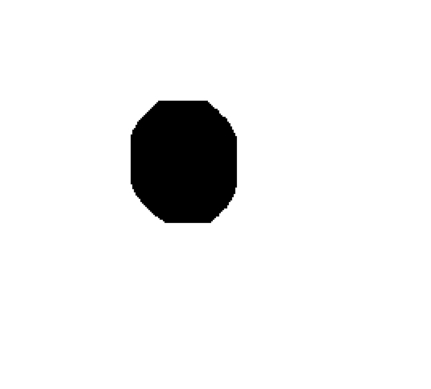

In [16]:
morpho_cross_eroded = erosion(morpho_binary_dilated_eroded, footprint=cross)

# visualizar
plt.imshow(morpho_cross_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.7 Calcule el máximo entre esta última imagen y la imagen original umbralizada. ¿Cómo es el resultado obtenido?

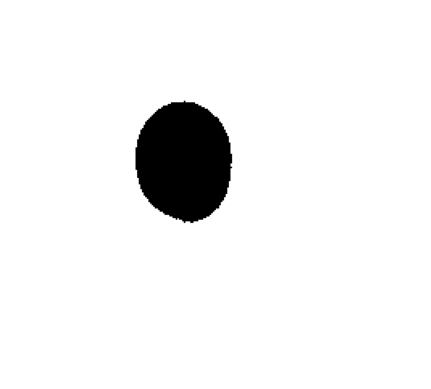

In [17]:
# maximo
max_img = np.maximum(morpho_cross_eroded, morpho_umbralized)

# visualizar
plt.imshow(max_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.8 Repita las operaciones 1 a 4, trabajando directamente con la imagen original no umbralizada (en niveles de gris).

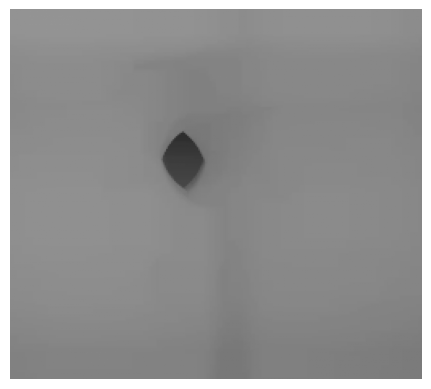

In [18]:
# dilatar con rectangulo de 29x29
structuring_element = footprint_rectangle(shape = (29, 29))
morpho_dilated = dilation(morpho_image, footprint=structuring_element)

# visualizar
plt.imshow(morpho_dilated, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

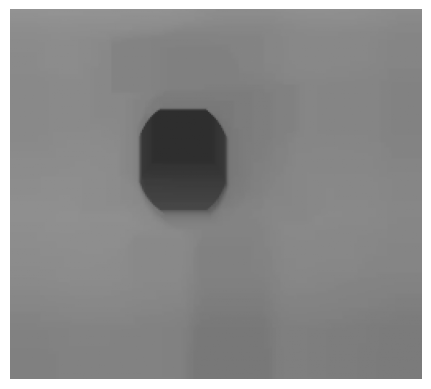

In [19]:
# erosionar con rectangulo de 29x29
morpho_dilated_eroded = erosion(morpho_dilated, footprint=structuring_element)

# visualizar
plt.imshow(morpho_dilated_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

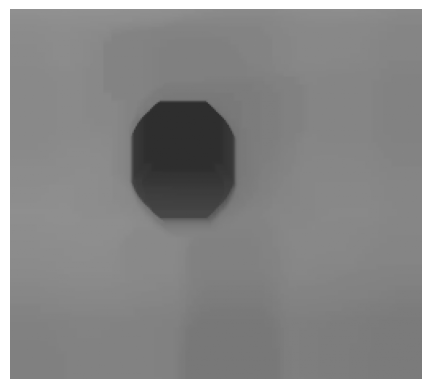

In [20]:
morpho_cross_eroded = erosion(morpho_dilated_eroded, footprint=cross)

# visualizar
plt.imshow(morpho_cross_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

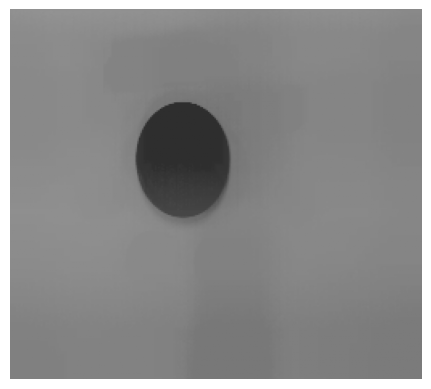

In [21]:
# maximo
max_img = np.maximum(morpho_cross_eroded, morpho_image)

# visualizar
plt.imshow(max_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

## 2. Gradiente morfológico

### 2.1 Cree una nueva sección en su notebook.

### 2.2 Cargue y visualice la imagen meb.png.

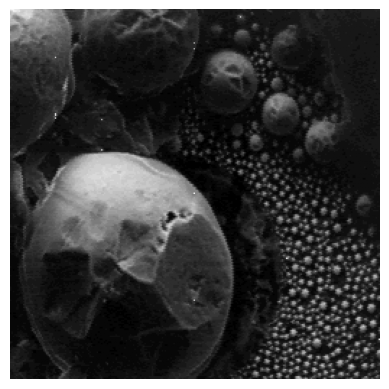

In [22]:
# cargar imagen meb
meb_image = cv2.imread(images_path+'meb.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(meb_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.3 Utilizando una máscara cuadrada de 3x3, calcule el gradiente morfológico de esta imagen.

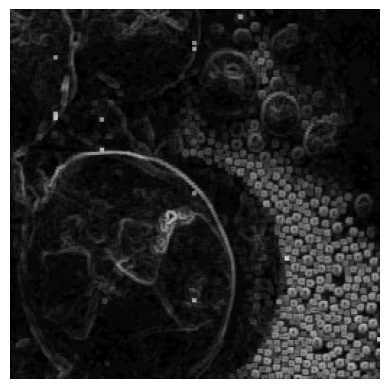

In [26]:
# mascara cuadrada de 3x3
structuring_element_3x3 = footprint_rectangle(shape = (3, 3))

# gradiente morfológico
mgimage = morphological_gradient(meb_image, footprint=structuring_element_3x3)

# visualizar
plt.imshow(mgimage, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.4 Genere la imagen de la norma del gradiente de la imagen meb.png con el operador de Sobel (ver Taller 3). Compare los resultados obtenidos (gradiente morfológico vs. norma del gradiente con Sobel). Puede efectuar una expansión del contraste sobre las dos imágenes obtenidas para visualizar mejor el resultado.

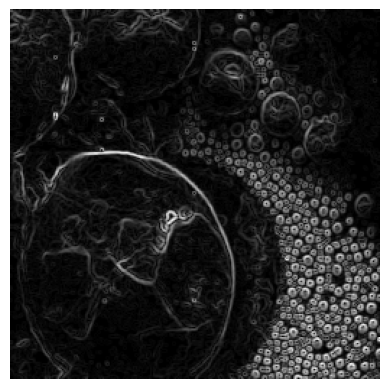

In [31]:
# norma del gradiente con Sobel
meb_sobel = sobel(meb_image)

# expandir contraste
meb_sobel_expanded = exposure.rescale_intensity(meb_sobel, in_range=(meb_sobel.min(),meb_sobel.max()), out_range=(0, 255))

# visualizar
plt.imshow(meb_sobel_expanded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.5 Repita la operación 3 empleando la misma máscara, pero SIN utilizar el operador de gradiente morfológico (créelo con los operadores de dilatación y de erosión, precedidos por un filtrado mediano). ¿Cómo es el resultado obtenido?

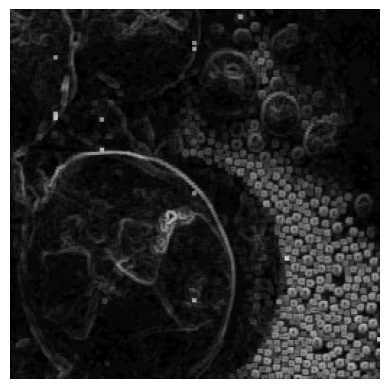

True


In [34]:
# calcular (A dilatar B) - (A erosionar B)
AdilatedB = dilation(meb_image, footprint=structuring_element_3x3)
AerosionB = erosion(meb_image, footprint=structuring_element_3x3)
morphological_gradient_manual = AdilatedB - AerosionB

# visualizar
plt.imshow(morphological_gradient_manual, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

print(np.all(mgimage == morphological_gradient_manual))

## 3. Operadores de apertura y cierre

### 3.1 Cree una nueva sección en su notebook.

### 3.2 Cargue y visualice la imagen amour.png.

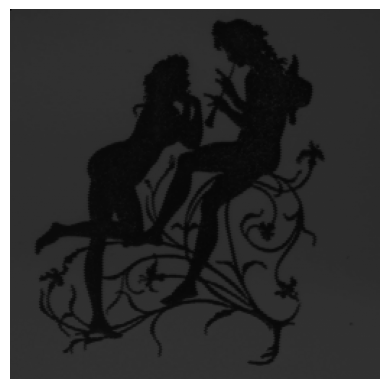

In [35]:
# imagen amour
amour_image = cv2.imread(images_path+'amour.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(amour_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.3 Realice la operación de apertura usando una máscara cuadrada de tamaño 5x5. ¿Qué partes fueron suprimidas? Nota: No es lo mismo aplicar dos veces seguidas la operación de apertura con una máscara de 3x3 que una sola vez con una máscara de 5x5. Hacer una segunda apertura no sirve de nada (no produce ningún efecto) ya que la operación de apertura es idempotente, es decir: apertura(apertura(imagen, máscara)) = apertura(imagen, máscara).

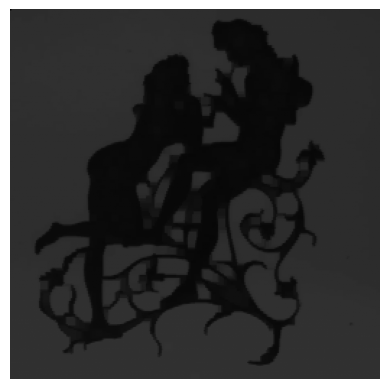

In [36]:
# crear la máscara
mask_square_5x5 = footprint_rectangle(shape=(5, 5))

# apertura
amour_open = opening(amour_image, footprint=mask_square_5x5)

# visualizar
plt.imshow(amour_open, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.4 Retome la imagen original, y aplique una umbralización para binarizarla (umbral = 35).

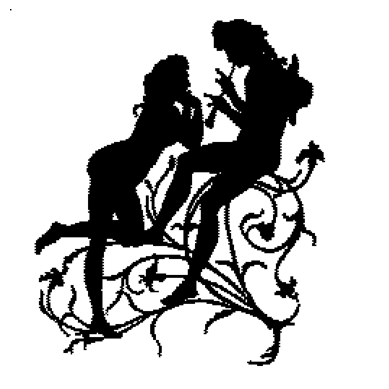

In [37]:
# umbralizacion de la imagen original
thres_value, amour_thresholded = cv2.threshold(amour_image, 35, 255, cv2.THRESH_BINARY)

# visualizar
plt.imshow(amour_thresholded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.5 Realice el cierre de la imagen. Para esto, efectúe 4 cierres aplicando sucesivamente las 4 máscaras lineales simétricas de tamaño 1x3 (en este orden: las dos diagonales ( / y después \ ), horizontal ( - ) y vertical ( | )). 

- Las máscaras diagonales (u oblicuas) deben crearse generando una matriz de 3x3 y colocando 1’ s sobre las diagonales. Los demás elementos se deben dejar vacíos (SIN CEROS).

- La máscara horizontal debe crearse generando una matriz de 3x1 llena de 1’s.

- La máscara vertical debe crearse generando una matriz de 1x3 llena de 1’s.

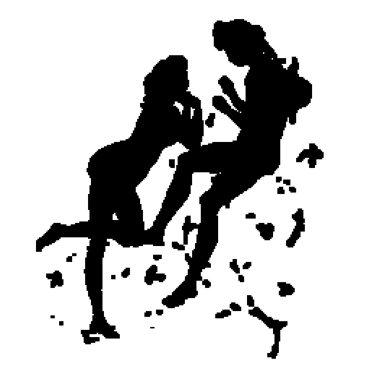

In [38]:
# diagonales
diag_principal = np.zeros((3, 3), dtype=np.uint8)
diag_principal[0, 0] = 1
diag_principal[1, 1] = 1
diag_principal[2, 2] = 1

diag_secundaria = np.zeros((3, 3), dtype=np.uint8)
diag_secundaria[0, 2] = 1
diag_secundaria[1, 1] = 1
diag_secundaria[2, 0] = 1

# horizontal
horizontal = np.ones((3, 1), dtype=np.uint8)

# vertical
vertical = np.ones((1, 3), dtype=np.uint8)

# realce:
# 1. diagonal secundaria
amour_closed_diag_sec = closing(amour_thresholded, footprint=diag_secundaria)
# 2. diagonal principal
amour_closed_diag_prin = closing(amour_closed_diag_sec, footprint=diag_principal)
# 3. horizontal
amour_closed_horizontal = closing(amour_closed_diag_prin, footprint=horizontal)
# 4. vertical
amour_closed_vertical = closing(amour_closed_horizontal, footprint=vertical)

# visualizar
plt.imshow(amour_closed_vertical, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.7 Tome el negativo de la imagen resultado, de tal manera que las figuras se vuelven blancas.

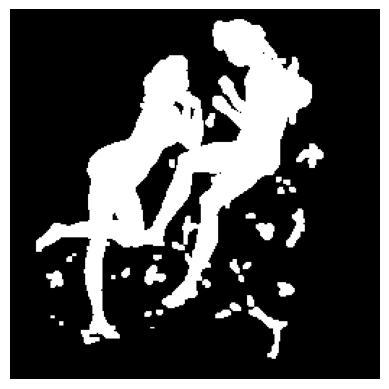

In [39]:
# negativo del resultado
neg_amour_realce = 255 - amour_closed_vertical

# visualizar
plt.imshow(neg_amour_realce, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.8 Seleccione el componente conexo más grande. ¿Cuál es el resultado?

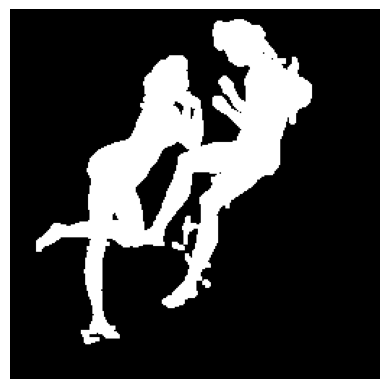

In [46]:
# componentes conexas
connected_components = label(neg_amour_realce, background=0, connectivity=2)

# tomar el más grande (distinto al fondo 0, el que mayor etiquetas tenga)
largest_label_component = 0
num_pixels_in_largest_component = 0
for i in range(1, connected_components.max() + 1):
    num_pixels = np.sum(connected_components == i)
    if num_pixels > num_pixels_in_largest_component:
        num_pixels_in_largest_component = num_pixels
        largest_label_component = i

connected_components[connected_components != largest_label_component] = 0
connected_components[connected_components == largest_label_component] = 255

# visualizar
plt.imshow(connected_components, cmap='gray')
plt.axis('off')
plt.show()

## 4. Etiquetado de objetos

### 4.1 Cree una nueva sección en su notebook.
### 4.2 Cargue y visualice la imagen sic.png.

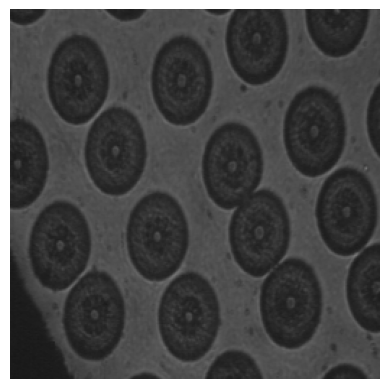

In [47]:
# cargar imagen sic
sic_image = cv2.imread(images_path+'sic.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(sic_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.3 Umbralice esta imagen de forma tal que las células del fondo sean separadas (umbral entre 55 y 70), y calcule su negativo.

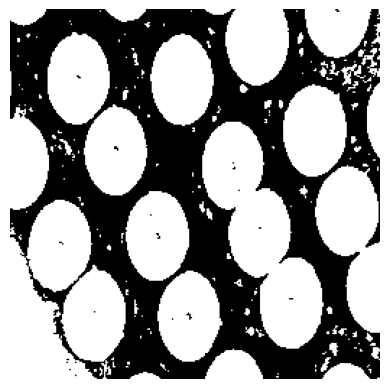

In [124]:
# umbralizar
thres_value, sic_thresholded = cv2.threshold(sic_image, 70, 255, cv2.THRESH_BINARY_INV)

# visualizar
plt.imshow(sic_thresholded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.4 Con una máscara en cruz de 3x3, haga dilataciones para rellenar los huecos al interior de las células.

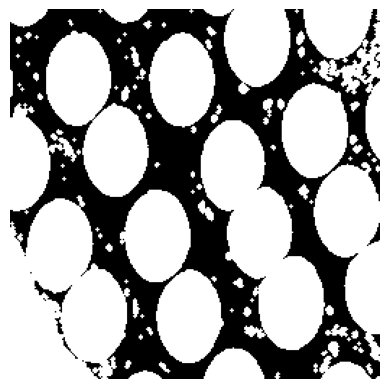

In [125]:
# crear máscara en cruz de 3x3
cross = np.zeros((3, 3), dtype=np.uint8)
cross[1, :] = 1
cross[:, 1] = 1

# dilatar con mascara en cruz
sic_dilated = dilation(sic_thresholded, footprint=cross)

# visualizar
plt.imshow(sic_dilated, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.5 Cambie de máscaras: se utilizarán ahora máscaras lineales (oblicuas). Utilice las mismas máscaras oblicuas creadas en el punto de apertura y cierre de este taller. Con el operador de erosión, separe las diferentes células. Ayuda: Para separar las células es necesario erosionar por lo menos 10 veces con una máscara lineal oblicua (/) y 6 veces con una máscara ortogonal a la primera (\).

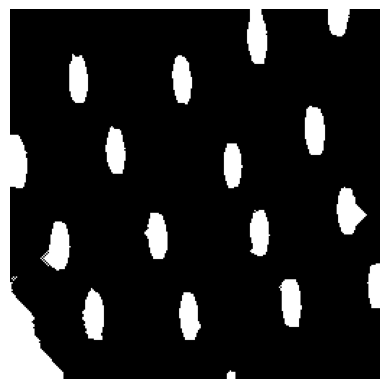

In [133]:
# diagonales
diag_principal = np.zeros((3, 3), dtype=np.uint8)
diag_principal[0, 0] = 1
diag_principal[1, 1] = 1
diag_principal[2, 2] = 1

diag_secundaria = np.zeros((3, 3), dtype=np.uint8)
diag_secundaria[0, 2] = 1
diag_secundaria[1, 1] = 1
diag_secundaria[2, 0] = 1

# erosionar 10 veces con la máscara lineal oblicua (/)
sic_eroded_diag_sec = sic_dilated.copy()
for _ in range(9):
    sic_eroded_diag_sec = erosion(sic_eroded_diag_sec, footprint=diag_secundaria)

# erosionar 6 veces con la máscara ortogonal a la primera (\)
sic_eroded_diag_prin = sic_eroded_diag_sec.copy()
for _ in range(7):
    sic_eroded_diag_prin = erosion(sic_eroded_diag_prin, footprint=diag_principal)

sic_final = sic_eroded_diag_prin

# visualizar
plt.imshow(sic_final, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

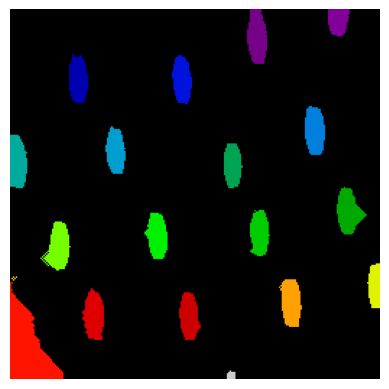

In [134]:
# etiquetar
connected_components = label(sic_final, background=0, connectivity=2)

# visualizar
plt.imshow(connected_components, cmap='nipy_spectral')
plt.axis('off')
plt.show()

## 5. Imagen de distancia

### 5.1 Cree una nueva sección en su notebook.
### 5.2 Cargue y visualice la imagen objects.png.

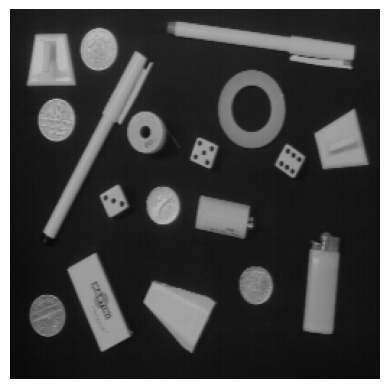

In [135]:
# cargar imagen objects
objects_image = cv2.imread(images_path+'objects.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(objects_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 5.3 Umbralice esta imagen para separar los objetos del fondo (umbral=70).

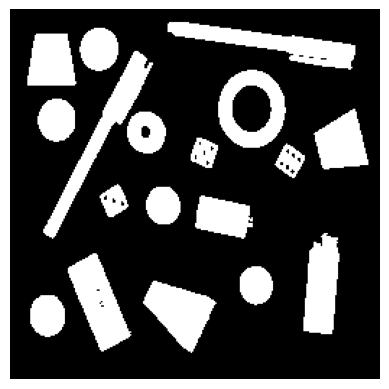

In [139]:
# umbralizar
thresh_value, objects_thresholded = cv2.threshold(objects_image, 70, 255, cv2.THRESH_BINARY)

# visualizar
plt.imshow(objects_thresholded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 5.4 Calcule la imagen de distancia. Puede efectuar una expansión del contraste sobre la imagen de distancia para visualizar mejor el resultado. Ajuste el Window/Level.

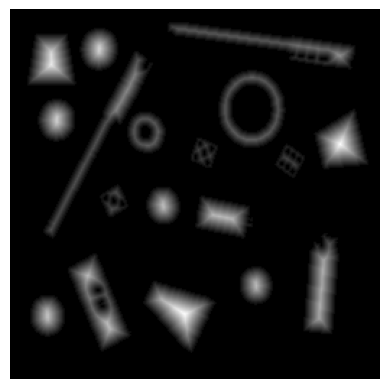

In [141]:
# calcular imagen de distancia
edm = distance_transform_edt(objects_thresholded)

# expansión de contraste
edm = exposure.rescale_intensity(edm, in_range=(edm.min(), edm.max()), out_range=(0, 255)).astype(np.uint8)

# visualizar
plt.imshow(edm, cmap='gray')
plt.axis('off')
plt.show()


### 5.5 Calcule ahora el negativo de la imagen umbralizada del punto 3. Ahora realice el cálculo de la distancia euclidiana. Utilizando la imagen resultante, determine la distancia mínima entre los dos lápices. Utilice máscaras y operaciones sobre pixeles para determinar el valor del pixel en el mapa de distancias a medio camino entre la distancia mínima de los dos lápices.

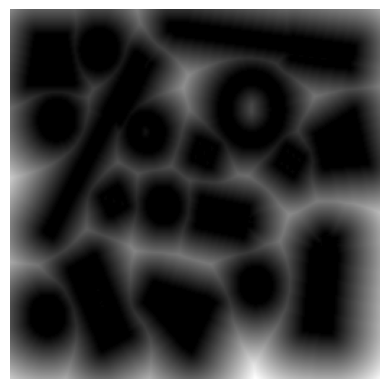

In [142]:
# negativo de umbral
objects_thresholded_neg = 255 - objects_thresholded

# distancia
distance_map = distance_transform_edt(objects_thresholded_neg)

# visualizar
plt.imshow(distance_map, cmap='gray')
plt.axis('off')
plt.show()

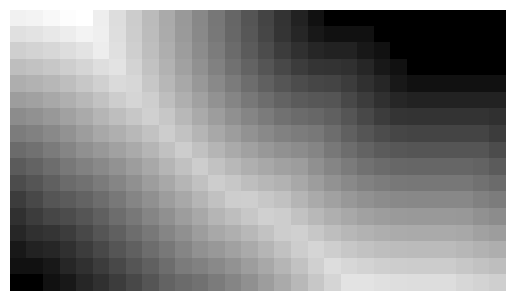

In [166]:
# Distancia mínima entre los lápices
# 1. tomar una ventana entre la cual están los dos lápices
mask_lapices = distance_map[15:32, 90:120]

# visualizar la ventana
plt.imshow(mask_lapices, cmap='gray')
plt.axis('off')
plt.show()

In [167]:
valor_medio_camino = np.max(mask_lapices)
valor_medio_camino

np.float64(15.0)